# TCGA Pan-Cancer RNA-Seq: exploratory data analysis

**Gene Expression Cancer RNA-Seq Dataset**
This dataset contains gene expression measurements from 801 cancer patients. For each patient we have the activity levels of 20,531 anonymized genes, measured using RNA sequencing.

The patients belong to one of five cancer types:

- Breast cancer (BRCA)
- Kidney cancer (KIRC)
- Colon cancer (COAD)
- Lung cancer (LUAD)
- Prostate cancer (PRAD)

The goal is to see whether we can tell which type of cancer a patient has just by looking at their gene expression pattern, and to explore how the different cancers cluster together.

## 1. Setup

If needed, install the libraries once by running `pip install numpy pandas matplotlib seaborn scipy scikit-learn` in a terminal or notebook cell.

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
PALETTE = 'colorblind'
sns.set_theme(style='whitegrid', context='notebook')

DATA_PATH = Path('/Users/rajveervora/Downloads/TCGA-PANCAN-HiSeq-801x20531/data.csv')
LABELS_PATH = Path('/Users/rajveervora/Downloads/TCGA-PANCAN-HiSeq-801x20531/labels.csv')
OUTPUT_DIR = Path('tcga_eda_results')
PLOTS_DIR = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

## 2. Load and validate the source data

The first column in each file is the sample ID. This cell stops if IDs are duplicated, unmatched, or expression values are missing or non-finite.

In [24]:
expression = pd.read_csv(DATA_PATH, index_col=0)
labels_df = pd.read_csv(LABELS_PATH, index_col=0)

if labels_df.shape[1] != 1:
    raise ValueError(f'Expected one label column, found {labels_df.shape[1]}.')
labels = labels_df.iloc[:, 0].rename('Class')

if expression.index.has_duplicates or labels.index.has_duplicates:
    raise ValueError('Sample IDs must be unique in both files.')
if not expression.index.equals(labels.index):
    raise ValueError('Sample IDs do not match exactly and in the same order.')

expression = expression.apply(pd.to_numeric, errors='raise')
if expression.isna().to_numpy().any() or not np.isfinite(expression.to_numpy()).all():
    raise ValueError('Expression matrix contains missing or infinite values.')

print(f'Expression matrix: {expression.shape[0]:,} samples × {expression.shape[1]:,} features')
print(f'Classes: {sorted(labels.unique())}')
expression.iloc[:5, :5]

Expression matrix: 801 samples × 20,531 features
Classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


,gene_0,gene_1,gene_2,gene_3,gene_4
sample_0,0.0,2.017209,3.265527,5.478487,10.431999
sample_1,0.0,0.592732,1.588421,7.586157,9.623011
sample_2,0.0,3.511759,4.327199,6.881787,9.870730
sample_3,0.0,3.663618,4.507649,6.659068,10.196184
sample_4,0.0,2.655741,2.821547,6.539454,9.738265


## 3. Class balance

Class counts determine whether a stratified split is needed in later modeling.

,Class,n_samples,percent
0,BRCA,300,37.453184
1,COAD,78,9.737828
2,KIRC,146,18.227216
3,LUAD,141,17.602996
4,PRAD,136,16.978777


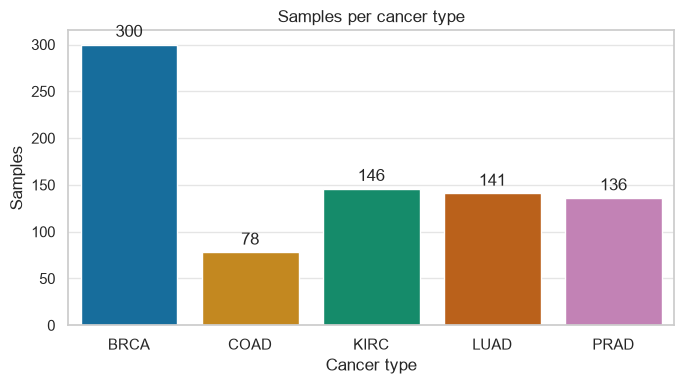

In [25]:
class_counts = labels.value_counts().sort_index().rename_axis('Class').reset_index(name='n_samples')
class_counts['percent'] = 100 * class_counts['n_samples'] / class_counts['n_samples'].sum()
display(class_counts)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=class_counts, x='Class', y='n_samples', hue='Class', legend=False, palette=PALETTE)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
ax.set(title='Samples per cancer type', xlabel='Cancer type', ylabel='Samples')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_class_balance.png', dpi=220, bbox_inches='tight')
plt.show()

## 4. Sample-level quality checks

Look for samples with unusual overall expression, spread, or zero fraction. They may represent valid biology, different preprocessing, or a data-quality issue.

mean_expression               median_expression                \
               median   mean    std            median   mean    std   
Class                                                                 
BRCA            6.438  6.414  0.144             7.599  7.577  0.186   
COAD            6.284  6.295  0.177             7.426  7.428  0.217   
KIRC            6.480  6.478  0.123             7.680  7.674  0.149   
LUAD            6.541  6.529  0.142             7.684  7.680  0.167   
PRAD            6.477  6.466  0.133             7.584  7.572  0.185   

      sd_expression               zero_fraction                \
             median   mean    std        median   mean    std   
Class                                                           
BRCA          4.063  4.069  0.067         0.141  0.144  0.016   
COAD          4.120  4.113  0.082         0.155  0.154  0.016   
KIRC          4.054  4.056  0.064         0.141  0.140  0.016   
LUAD          4.015  4.015  0.076         0.138  0.139  0.016   
PRAD          4.026  4.029  0.060         0.136  0.138  0.014   

      detected_features                      
                 median       mean      std  
Class                                        
BRCA            17633.0  17576.920  319.251  
COAD            17356.0  17378.346  325.650  
KIRC            17639.0  17651.301  328.702  
LUAD            17702.0  17686.752  320.547  
PRAD            17746.0  17703.662  285.397

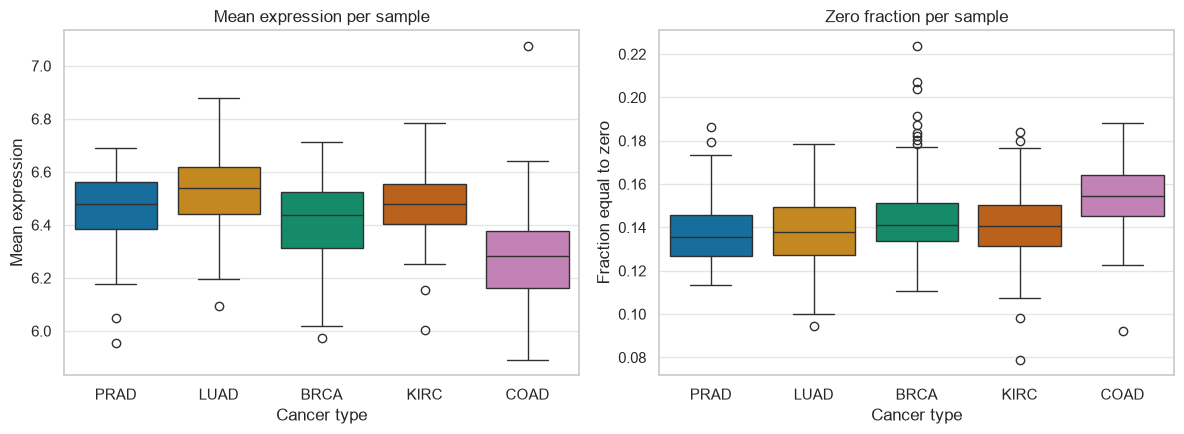

In [26]:
X = expression.to_numpy()
sample_qc = pd.DataFrame({
    'Class': labels,
    'mean_expression': X.mean(axis=1),
    'median_expression': np.median(X, axis=1),
    'sd_expression': X.std(axis=1, ddof=1),
    'zero_fraction': (X == 0).mean(axis=1),
    'detected_features': (X > 0).sum(axis=1)
}, index=expression.index)
sample_qc.index.name = 'sample_id'
display(sample_qc.groupby('Class').agg(['median', 'mean', 'std']).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=sample_qc, x='Class', y='mean_expression', hue='Class', legend=False, palette=PALETTE, ax=axes[0])
sns.boxplot(data=sample_qc, x='Class', y='zero_fraction', hue='Class', legend=False, palette=PALETTE, ax=axes[1])
axes[0].set(title='Mean expression per sample', xlabel='Cancer type', ylabel='Mean expression')
axes[1].set(title='Zero fraction per sample', xlabel='Cancer type', ylabel='Fraction equal to zero')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_sample_qc_by_class.png', dpi=220, bbox_inches='tight')
plt.show()

sample_qc.to_csv(OUTPUT_DIR / 'sample_qc.csv')

## 5. Feature-level summary

High-variance features are useful for visualizing broad structure. A high variance alone does not make a feature biologically important.

,gene,mean_expression,median_expression,sd_expression,variance,zero_fraction,detected_samples,coefficient_of_variation
0,gene_9176,3.946748,0.502942,6.690579,44.763849,0.450687,440,1.695213
1,gene_9175,3.771632,1.069083,6.030086,36.361940,0.293383,566,1.598800
2,gene_15898,3.621030,0.925468,5.874003,34.503915,0.215980,628,1.622191
3,gene_15301,5.506275,1.547499,5.784356,33.458776,0.380774,496,1.050503
4,gene_15589,3.849006,0.000000,5.596950,31.325845,0.539326,369,1.454128
5,gene_3540,7.103013,6.620104,5.530614,30.587696,0.119850,705,0.778629
6,gene_19661,7.785158,10.126846,5.484567,30.080478,0.079900,737,0.704490
7,gene_3541,8.351401,8.042119,5.359262,28.721689,0.071161,744,0.641720
8,gene_11250,5.110965,3.655581,5.149358,26.515887,0.225968,620,1.007512
9,gene_15897,5.712919,3.894372,5.100926,26.019446,0.056180,756,0.892876


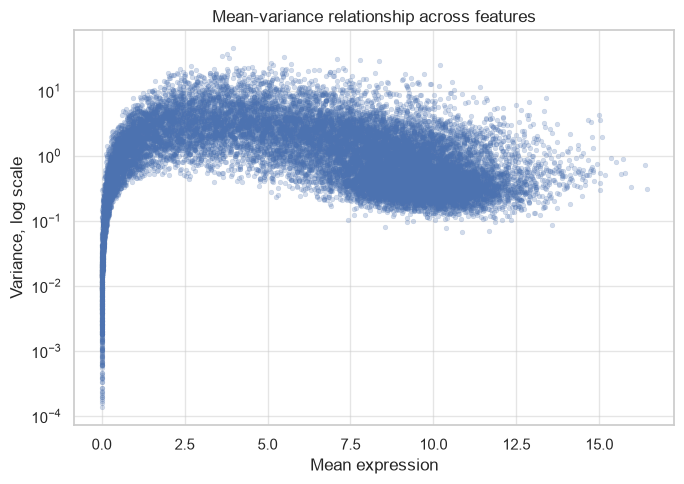

In [27]:
gene_summary = pd.DataFrame({
    'gene': expression.columns,
    'mean_expression': X.mean(axis=0),
    'median_expression': np.median(X, axis=0),
    'sd_expression': X.std(axis=0, ddof=1),
    'variance': X.var(axis=0, ddof=1),
    'zero_fraction': (X == 0).mean(axis=0),
    'detected_samples': (X > 0).sum(axis=0),
}).sort_values('variance', ascending=False, ignore_index=True)
gene_summary['coefficient_of_variation'] = gene_summary['sd_expression'] / gene_summary['mean_expression'].replace(0, np.nan)
display(gene_summary.head(20))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=gene_summary, x='mean_expression', y='variance', alpha=0.25, edgecolor=None, s=12)
plt.yscale('log')
plt.title('Mean-variance relationship across features')
plt.xlabel('Mean expression')
plt.ylabel('Variance, log scale')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_gene_mean_variance.png', dpi=220, bbox_inches='tight')
plt.show()

gene_summary.to_csv(OUTPUT_DIR / 'gene_summary.csv', index=False)

## 6. PCA: global sample structure

PCA is run after scaling each feature to mean 0 and standard deviation 1. This keeps a few large-range features from driving the view solely because of scale.

,Class,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
sample_id,,,,,,,,,,,
sample_0,PRAD,-57.446987,-95.410981,74.301543,12.166781,-7.981831,-36.157573,-7.668542,19.951444,0.142214,-3.035235
sample_1,LUAD,-16.919430,-0.732470,-64.072900,2.095308,25.426430,-27.784178,-16.132765,-17.031382,-22.023874,27.923306
sample_2,PRAD,-70.345218,19.303327,20.488240,-48.102893,-24.437757,-17.462510,20.706772,-47.626817,-28.647648,12.784684
sample_3,PRAD,-49.161591,9.227586,61.243770,-37.805744,-1.038889,-23.240002,-4.801039,-21.554809,-15.375067,12.881512
sample_4,BRCA,-18.132534,51.327797,16.598116,17.699201,-26.389130,1.551573,-6.266101,12.336677,-4.233837,-28.804471


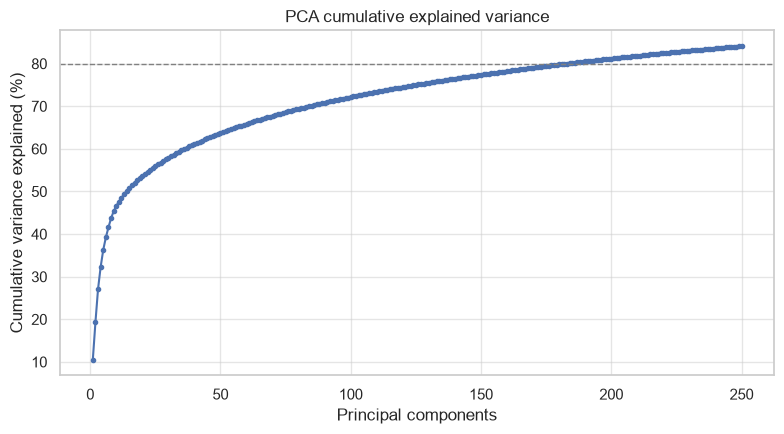

In [ ]:
X_scaled = StandardScaler().fit_transform(expression)
n_components = min(250, X_scaled.shape[0] - 1, X_scaled.shape[1])
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
pca_scores = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

pca_coordinates = pd.DataFrame(pca_scores[:, :10], index=expression.index, columns=[f'PC{i}' for i in range(1, 11)])
pca_coordinates.insert(0, 'Class', labels)
pca_coordinates.index.name = 'sample_id'
display(pca_coordinates.head())

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker='o', markersize=3)
plt.axhline(80, color='grey', linestyle='--', linewidth=1)
plt.title('PCA cumulative explained variance')
plt.xlabel('Principal components')
plt.ylabel('Cumulative variance explained (%)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_pca_variance_explained.png', dpi=220, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_coordinates, x='PC1', y='PC2', hue='Class', palette=PALETTE, s=48, alpha=0.85)
plt.title('PCA of standardized expression')
plt.xlabel(f'PC1 ({explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({explained[1]:.1f}% variance)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Cancer type')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_pca_pc1_pc2.png', dpi=220, bbox_inches='tight')
plt.show()

pca_coordinates.to_csv(OUTPUT_DIR / 'pca_coordinates.csv')

## 7. Heatmap of the most variable features

Each feature is z-scored across samples. Colors show relative expression patterns, not absolute expression levels. Rows are sorted by cancer class and columns are clustered.

In [ ]:
TOP_N = 50
top_genes = gene_summary.head(TOP_N)['gene'].tolist()
heatmap_values = expression[top_genes]
heatmap_z = (heatmap_values - heatmap_values.mean(axis=0)) / heatmap_values.std(axis=0, ddof=1)
ordered_samples = labels.sort_values(kind='stable').index
classes = sorted(labels.unique())
class_to_color = dict(zip(classes, sns.color_palette(PALETTE, len(classes))))
row_colors = labels.loc[ordered_samples].map(class_to_color)

grid = sns.clustermap(
    heatmap_z.loc[ordered_samples], row_cluster=False, col_cluster=True,
    row_colors=row_colors, cmap='vlag', center=0, xticklabels=False, yticklabels=False,
    figsize=(12, 9), cbar_kws={'label': 'Feature-wise z score'}
)
grid.fig.suptitle(f'Patterns in the {TOP_N} most variable features', y=1.02)
grid.savefig(PLOTS_DIR / '06_top_variable_feature_heatmap.png', dpi=220, bbox_inches='tight')
plt.show()

## 8. Sample similarity

The correlation matrix uses the 1,000 most variable features. Samples with very low average similarity may be worth inspecting alongside PCA and sample QC.

In [ ]:
variable_features = expression.var(axis=0).nlargest(1000).index
sample_correlation = expression[variable_features].T.corr()
mean_similarity = (sample_correlation.sum(axis=1) - 1) / (len(sample_correlation) - 1)
sample_similarity = pd.DataFrame({'Class': labels, 'mean_sample_correlation': mean_similarity})
sample_similarity.index.name = 'sample_id'
display(sample_similarity.sort_values('mean_sample_correlation').head(15))

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=sample_similarity, x='Class', y='mean_sample_correlation', hue='Class', legend=False, palette=PALETTE)
plt.title('Average similarity to all other samples')
plt.xlabel('Cancer type')
plt.ylabel('Mean Pearson correlation')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '07_sample_similarity_by_class.png', dpi=220, bbox_inches='tight')
plt.show()

sample_similarity.to_csv(OUTPUT_DIR / 'sample_similarity.csv')